# ZORA : CNN Deconv Topological studies

Study the performance of NEXT classical toplogocal method using data previously deconvoluted bu Martin's CNN

27/11/24 Santiago

In [152]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

In [153]:
import glob
import sys
from os import listdir
from collections import namedtuple
import itertools as itertools

In [154]:
import numpy             as np
import pandas            as pd
import tables            as tb
from   scipy             import stats
from   scipy             import optimize
import networkx as nx

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

plt.rcParams['image.cmap'] = 'rainbow'

In [155]:
pypaths = ('/home/usc/ie/jhm/NEXT/nextana',
           '/home/usc/ie/jhm/NEXT/hipy', 
           '/home/usc/ie/jjhm/NEXT/IC')
for ipypath in pypaths:
       sys.path.insert(0,ipypath)

In [156]:
import nana.topo.evtfun    as evtfun
import nana.topo.graphfun  as graphfun
import nana.topo.zora      as zora

In [157]:
import hipy.utils        as ut

#import hipy.histos       as histos
import hipy.pltext       as pltext
#import hipy.profile      as prof
#from invisible_cities.io.dst_io import load_dst, load_dsts
from hipy.styles import style

## Load Data

In [158]:
datafilename = 'dataset_15607_DEP_deco.h5'
mcfilename   = 'dataset_4bar_MC_DEP_deco.h5'
datapath     = '/mnt/netapp1/Store_next_data/NEXT100/deco_seg/'

In [159]:
ifilename = datapath + mcfilename
print(f'loading {ifilename}')
data     =  pd.read_hdf(ifilename, 'DATASET/Voxels');
bin_info =  pd.read_hdf(ifilename, 'DATASET/BinsInfo');
bin_widths  = evtfun.get_bin_widths(bin_info)

loading /mnt/netapp1/Store_next_data/NEXT100/deco_seg/dataset_4bar_MC_DEP_deco.h5


In [41]:
datadeco   = evtfun.get_deconvoluted_data(data)
#evtfun.test_get_deconvoluted_data(data)

In [42]:
datadeco

,dataset_id,binclass,xbin,ybin,zbin,energy,decolabel,decoscore,decopred,segclass,extlabel,enecc,enecn
0,0,0,37,51,52,0.000402,0,0.009006,0,2,0,0.0,0.0
1,0,0,38,43,52,0.000832,0,0.017880,0,2,0,0.0,0.0
2,0,0,38,44,52,0.000463,0,0.013932,0,2,0,0.0,0.0
3,0,0,38,47,52,0.000436,0,0.009499,0,2,0,0.0,0.0
4,0,0,38,47,53,0.000938,0,0.011403,0,2,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5280416,15037,1,30,30,60,0.000395,0,0.081036,0,2,0,0.0,0.0
5280417,15037,1,30,31,60,0.000821,0,0.045941,0,2,0,0.0,0.0
5280418,15037,1,30,33,61,0.000355,0,0.019439,0,2,0,0.0,0.0
5280419,15037,1,30,34,61,0.000409,0,0.022328,0,2,0,0.0,0.0


## Event loop

In [58]:
groupid = 'dataset_id'
evtdata = data.groupby(groupid)

In [141]:
ievt = 4
evt = evtdata.get_group(ievt)

In [142]:
evt.head()

,dataset_id,binclass,xbin,ybin,zbin,energy,decolabel,decoscore,decopred,segclass,extlabel,enecc,enecn
1390,4,0,11,16,24,0.002182,0,0.024158,0,1,0,0.0,0.0
1391,4,0,11,16,27,0.000394,0,0.042762,0,1,0,0.0,0.0
1392,4,0,11,17,24,0.001047,0,0.020391,0,1,0,0.0,0.0
1393,4,0,11,18,24,0.001084,0,0.024498,0,1,0,0.0,0.0
1394,4,0,12,14,24,0.001824,0,0.031505,0,1,0,0.0,0.0


In [143]:
zevt = zora.zora_event(evt, bin_info, bin_widths)

,ext_ene,ext_degree,ext_dist,blob_id,blob_ene,blob_nodes,blob_edges,blob_mcext_dist,blob_mcext_closenode,blob_mcseg,dataset_id,binclass,nhits,energy,spine_nhits,spine_energy,ngraphs,lgraph_nodes,lgraph_edges,lgraph_energy
0,0.042588,7,4,0,0.380247,14,52,0.000000,True,2,4,0,296,1.0,37,0.381829,2,22,93,0.541041
1,0.016994,5,4,1,0.372701,17,69,1.414214,False,0,4,0,296,1.0,37,0.381829,2,22,93,0.541041


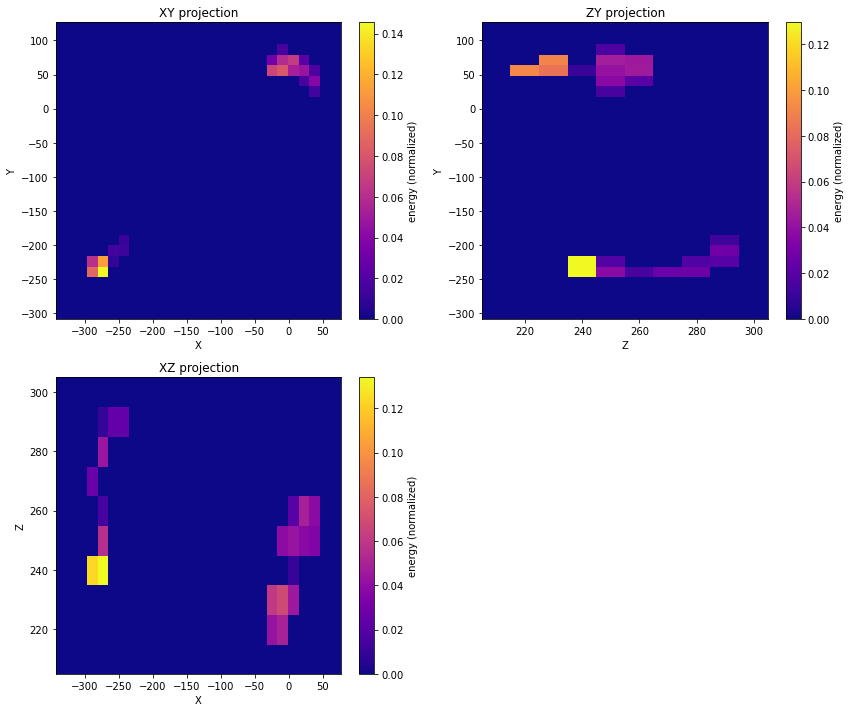

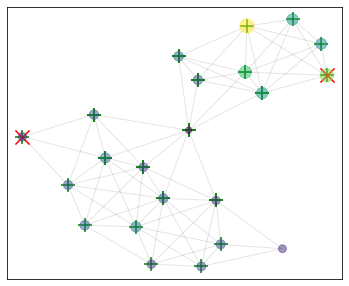

In [144]:
coors = evtfun.get_coors(evt, bin_info)
ene   = evt.enecn.values
bins  = evtfun.get_bins(coors, bin_widths)
evtfun.event_display(coors, bins = bins, ene = ene);

pltext.canvas(1, 1)
longest_graph = zevt['longest_graph']
extremes      = zevt['extremes']
blobs        = zevt['blobs']
graphfun.display_graph(longest_graph, extremes, blobs)

zevt['summary'].head()

## Run ZORA

In [161]:
print(mcfilename)

dataset_4bar_MC_DEP_deco.h5


In [186]:
dfout = zora.zora(ifilename = mcfilename, nevents = -1)

loading /mnt/netapp1/Store_next_data/NEXT100/deco_seg/dataset_4bar_MC_DEP_deco.h5
Number of events in input file 15038
Number of events to process 15037
Event 0
No extremes  [35] []
No extremes  [130] []
No extremes  [178] []
No extremes  [226] []
No extremes  [275] []
No extremes  [294] []
No extremes  [363] []
No extremes  [439] []
No extremes  [445] []
Event 500
No extremes  [552] []
No extremes  [638] []
No extremes  [646] []
No extremes  [742] []
No extremes  [744] []
No extremes  [860] []
No extremes  [865] []
No extremes  [906] []
No extremes  [970] []
Event 1000
No extremes  [1045] []
No extremes  [1057] []
No extremes  [1083] []
No extremes  [1133] []
No extremes  [1137] []
No extremes  [1155] []
No extremes  [1213] []
No extremes  [1222] []
No extremes  [1273] []
No extremes  [1347] []
No extremes  [1489] []
Event 1500
No extremes  [1504] []
No extremes  [1516] []
No extremes  [1571] []
No extremes  [1631] []
No extremes  [1636] []
No extremes  [1650] []
No extremes  [1673] [

In [187]:
dfout.head()

,ext_ene,ext_degree,ext_dist,blob_id,blob_ene,blob_nodes,blob_edges,blob_mcext_dist,blob_mcext_closenode,blob_mcseg,dataset_id,binclass,nhits,energy,spine_nhits,spine_energy,ngraphs,lgraph_nodes,lgraph_edges,lgraph_energy
0,0.005626,13,16,0,0.435297,72,584,0.000000,True,35.0,1,0,378,1.0,241,0.829546,2,240,1819,0.985380
1,0.001302,5,16,1,0.070860,24,140,11.224972,False,0.0,1,0,378,1.0,241,0.829546,2,240,1819,0.985380
2,0.000910,10,12,0,0.179905,40,277,5.830952,False,0.0,2,1,267,1.0,205,0.943462,7,199,1573,0.996518
3,0.000344,3,12,1,0.006244,6,13,2.236068,False,6.0,2,1,267,1.0,205,0.943462,7,199,1573,0.996518
4,0.004336,10,17,0,0.253746,33,236,0.000000,True,2.0,3,1,362,1.0,183,0.736879,2,182,1433,0.998303


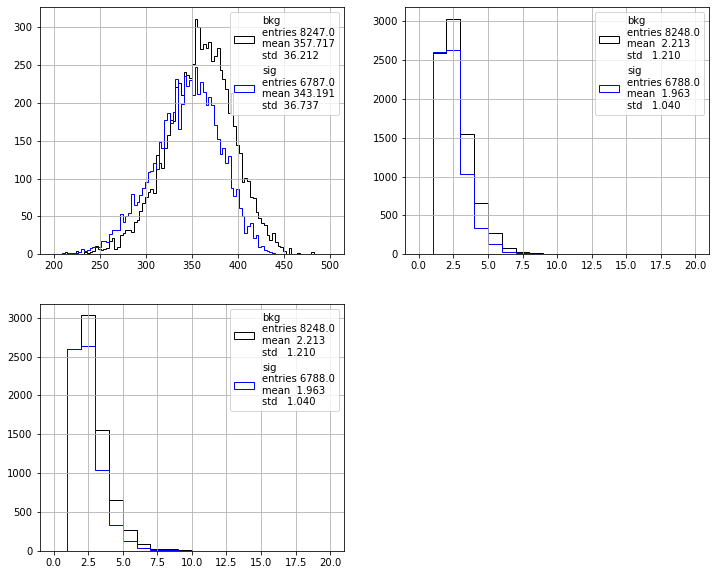

In [192]:
cv = pltext.canvas(4, 2)
seluni = dfout.blob_id == 0
selbkg = dfout.binclass == 0
selsig = dfout.binclass == 1

dfuni = dfout[seluni]

cv(1); 
pltext.hist(dfuni[selbkg].nhits, 100, (200, 500), label = 'bkg');
pltext.hist(dfuni[selsig].nhits, 100, (200, 500), label = 'sig');
cv(2); 
pltext.hist(dfuni[selbkg].ngraphs, 20, (0, 20), label = 'bkg');
pltext.hist(dfuni[selsig].ngraphs, 20, (0, 20), label = 'sig');
cv(3); 
pltext.hist(dfuni[selbkg].ngraphs, 20, (0, 20), label = 'bkg');
pltext.hist(dfuni[selsig].ngraphs, 20, (0, 20), label = 'sig');




In [190]:
vars = ['ext_ene',
 'ext_degree',
 'ext_dist',
 'blob_id',
 'blob_ene',
 'blob_nodes',
 'blob_edges',
 'blob_mcext_dist',
 'blob_mcseg',
 'dataset_id',
 'binclass',
 'nhits',
 'energy',
 'spine_nhits',
 'spine_energy',
 'ngraphs',
 'lgraph_nodes',
 'lgraph_edges',
 'lgraph_energy']

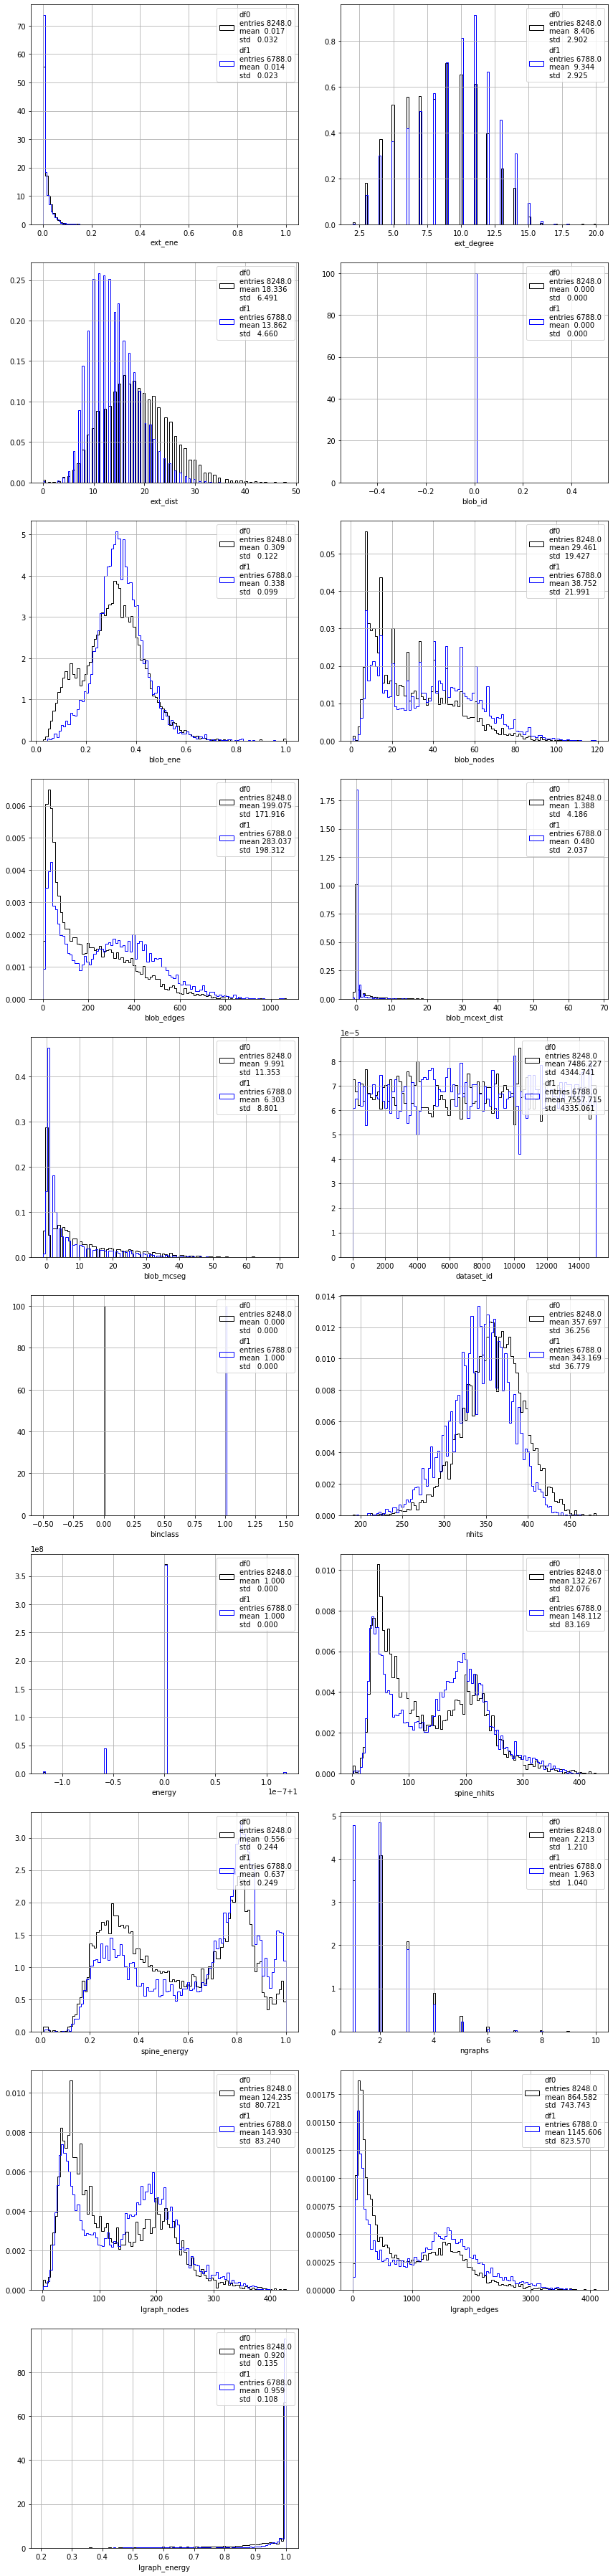

In [ ]:
pltext.df_inspect((dfuni[selbkg], dfuni[selsig]), labels = vars, density = True)